# Facteur de Correction Markowitz/Xu (MX) — Data Mining Bias

**Objectif :** Comprendre et implémenter la méthode de *shrinkage* qui corrige le biais de minage de données dans les backtests sans sacrifier une partie de l'historique.

## Introduction

Quand on teste **des milliers de règles de trading** sur le même jeu de données, la meilleure règle trouvée a bénéficié d'une **part de chance**.

Ce phénomène s'appelle le **biais de minage de données** (*data mining bias*) : plus on teste de règles, plus la probabilité que la "meilleure" soit simplement chanceuse augmente.

La solution classique est le test **Out-of-Sample (OOS)** : réserver une partie de l'historique pour valider. Mais cette approche **consomme des données précieuses**.

La méthode **Markowitz/Xu (MX)** propose une alternative purement statistique :

> Appliquer une "amende mathématique" à la performance observée, sans toucher à l'historique.

## Intuition

Imaginons un concours de pronostics entre **1 000 personnes**.

- Le gagnant atteint **90\% de réussite**.
- Mais sur 1 000 participants, il est *mathématiquement inévitable* qu'un participant chanceux émerge.
- Est-il vraiment talentueux à 90\%, ou simplement chanceux ?

La méthode MX dit : **"Rabattons ce score de 90\% vers la moyenne du groupe."**

Si la moyenne du groupe est 50\%, peut-être que le vrai talent de ce gagnant vaut 60-65\%.

C'est le principe du **shrinkage** (contraction) :

- On **ramène le champion vers la moyenne** de tous les candidats testés.
- L'intensité de la correction dépend du **facteur B** — plus on a testé de règles, plus la contraction est forte.

## Développement Théorique

### La formule centrale

$$H' = R + B \cdot (H - R)$$

**Composants :**

| Symbole | Nom | Signification |
|---|---|---|
| $H$ | Observed Performance | Rendement brut du meilleur candidat (backtest) |
| $R$ | Average Return | Moyenne des rendements de **toutes** les règles testées |
| $B$ | Shrinkage Factor | Facteur entre 0 et 1 mesurant la part de talent vs chance |
| $H'$ | Adjusted Performance | Rendement attendu après correction du biais |

---

### Le facteur B

Le facteur $B$ est le **cœur de la méthode**. Il se calcule comme :

$$B = \frac{\sigma_R^2 / N}{\sigma_R^2 / N + \sigma_H^2 / T}$$

Où :
- $\sigma_R^2$ = variance de la **distribution des moyennes** de toutes les règles (dispersion inter-règles)
- $\sigma_H^2$ = variance des **rendements quotidiens** de la meilleure règle (bruit interne)
- $N$ = nombre de règles testées
- $T$ = nombre de périodes (observations temporelles)

**Interprétation de B :**

- $B \approx 0$ → Biais énorme : $H' \approx R$ (le champion ne vaut guère mieux que la moyenne)
- $B \approx 1$ → Biais négligeable : $H' \approx H$ (la performance observée est fiable)

---

### Ce qui fait baisser B (et donc augmenter la correction)

- **Plus de règles testées** ($N$ élevé) → B diminue
- **Peu d'observations** ($T$ faible) → B diminue  
- **Grande variance interne** de la règle ($\sigma_H^2$ élevé) → B diminue
- **Faible dispersion** entre les règles ($\sigma_R^2$ faible) → B diminue

## Implémentation Python

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Configuration graphique
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
print("Libraries chargées.")

Libraries chargées.


In [2]:
def markowitz_xu_correction(H, R, sigma_R_sq, sigma_H_sq, N, T):
    """
    Calcule le rendement ajusté selon la méthode Markowitz/Xu.

    Paramètres
    ----------
    H         : float  — Rendement observé du meilleur candidat
    R         : float  — Rendement moyen de toutes les règles testées
    sigma_R_sq: float  — Variance des moyennes inter-règles
    sigma_H_sq: float  — Variance des rendements quotidiens de la meilleure règle
    N         : int    — Nombre de règles testées
    T         : int    — Nombre de périodes (observations)

    Retourne
    --------
    dict contenant H_prime (ajusté), B (shrinkage factor) et les inputs
    """
    # Calcul du facteur B (part attribuée au signal vs bruit)
    signal_component = sigma_R_sq / N
    noise_component  = sigma_H_sq / T
    B = signal_component / (signal_component + noise_component)

    # Application de la formule de shrinkage
    H_prime = R + B * (H - R)

    return {
        'H_observed':   H,
        'R_average':    R,
        'B_shrinkage':  round(B, 4),
        'H_adjusted':   round(H_prime, 6),
        'Degradation':  round(H - H_prime, 6),
        'N_rules':      N,
        'T_periods':    T
    }

print("Fonction markowitz_xu_correction définie.")

Fonction markowitz_xu_correction définie.


In [3]:
# ─── Exemple de base ────────────────────────────────────────────────────────
# Scénario : on a testé 500 règles sur 252 jours de trading
# La meilleure règle génère 15% annualisé, la moyenne est à 2%

result = markowitz_xu_correction(
    H          = 0.15,    # Meilleure règle : +15% annuel
    R          = 0.02,    # Moyenne de toutes les règles : +2%
    sigma_R_sq = 0.001,   # Faible dispersion entre les règles
    sigma_H_sq = 0.0004,  # Variance des rendements quotidiens de la gagnante
    N          = 500,     # 500 règles testées
    T          = 252      # 1 an de trading
)

print("=" * 45)
print("  RÉSULTATS MARKOWITZ/XU")
print("=" * 45)
for k, v in result.items():
    print(f"  {k:<20} : {v}")
print("=" * 45)
print(f"\n  → Performance AVANT correction : {result['H_observed']*100:.1f}%")
print(f"  → Performance APRÈS correction : {result['H_adjusted']*100:.1f}%")
print(f"  → Dégradation estimée          : {result['Degradation']*100:.1f} points")

  RÉSULTATS MARKOWITZ/XU
  H_observed           : 0.15
  R_average            : 0.02
  B_shrinkage          : 0.5575
  H_adjusted           : 0.092478
  Degradation          : 0.057522
  N_rules              : 500
  T_periods            : 252

  → Performance AVANT correction : 15.0%
  → Performance APRÈS correction : 9.2%
  → Dégradation estimée          : 5.8 points


## Exemple d'Application : Simulation Monte Carlo + MX

On va simuler un **univers de règles aléatoires** (sans signal réel), puis appliquer la correction MX pour visualiser l'effet du shrinkage selon le nombre de règles testées.

In [4]:
np.random.seed(42)

def simulate_rules_universe(n_rules, n_days, true_edge=0.0):
    """
    Simule un univers de règles de trading aléatoires.

    Paramètres
    ----------
    n_rules   : int   — Nombre de règles à simuler
    n_days    : int   — Nombre de jours de trading
    true_edge : float — Avantage réel moyen (0 = pur bruit)

    Retourne
    --------
    DataFrame (n_days x n_rules) des rendements journaliers
    """
    daily_vol = 0.01  # Volatilité journalière typique
    # Rendements aléatoires centrés sur true_edge/252
    returns = np.random.normal(
        loc   = true_edge / 252,
        scale = daily_vol,
        size  = (n_days, n_rules)
    )
    return pd.DataFrame(returns, columns=[f'Rule_{i}' for i in range(n_rules)])


def analyze_universe(returns_df):
    """
    Calcule les statistiques nécessaires à la formule MX.
    """
    T, N = returns_df.shape

    # Moyenne annualisée par règle
    mean_returns = returns_df.mean() * 252

    H        = mean_returns.max()     # Meilleure règle
    R        = mean_returns.mean()    # Moyenne de l'univers

    # Variance inter-règles (dispersion des moyennes)
    sigma_R_sq = mean_returns.var()

    # Variance intra-règle (bruit journalier du champion)
    best_rule  = mean_returns.idxmax()
    sigma_H_sq = (returns_df[best_rule] * 252).var()

    return H, R, sigma_R_sq, sigma_H_sq, N, T


# ─── Analyse pour différents nombres de règles ──────────────────────────────
n_rules_list = [10, 50, 100, 500, 1000, 5000]
n_days       = 504  # 2 ans de données

results = []

for n in n_rules_list:
    df = simulate_rules_universe(n_rules=n, n_days=n_days, true_edge=0.0)
    H, R, sigma_R_sq, sigma_H_sq, N, T = analyze_universe(df)
    res = markowitz_xu_correction(H, R, sigma_R_sq, sigma_H_sq, N, T)
    results.append(res)

results_df = pd.DataFrame(results)
results_df['N_rules'] = n_rules_list
print(results_df[['N_rules', 'H_observed', 'R_average', 'B_shrinkage', 'H_adjusted']].to_string(index=False))

 N_rules  H_observed  R_average  B_shrinkage  H_adjusted
      10    0.183741   0.016741       0.0691    0.028285
      50    0.380562  -0.004189       0.0188    0.003053
     100    0.332645   0.002956       0.0100    0.006268
     500    0.294421  -0.002179       0.0024   -0.001462
    1000    0.324150  -0.001725       0.0010   -0.001395
    5000    0.391991  -0.001360       0.0002   -0.001276


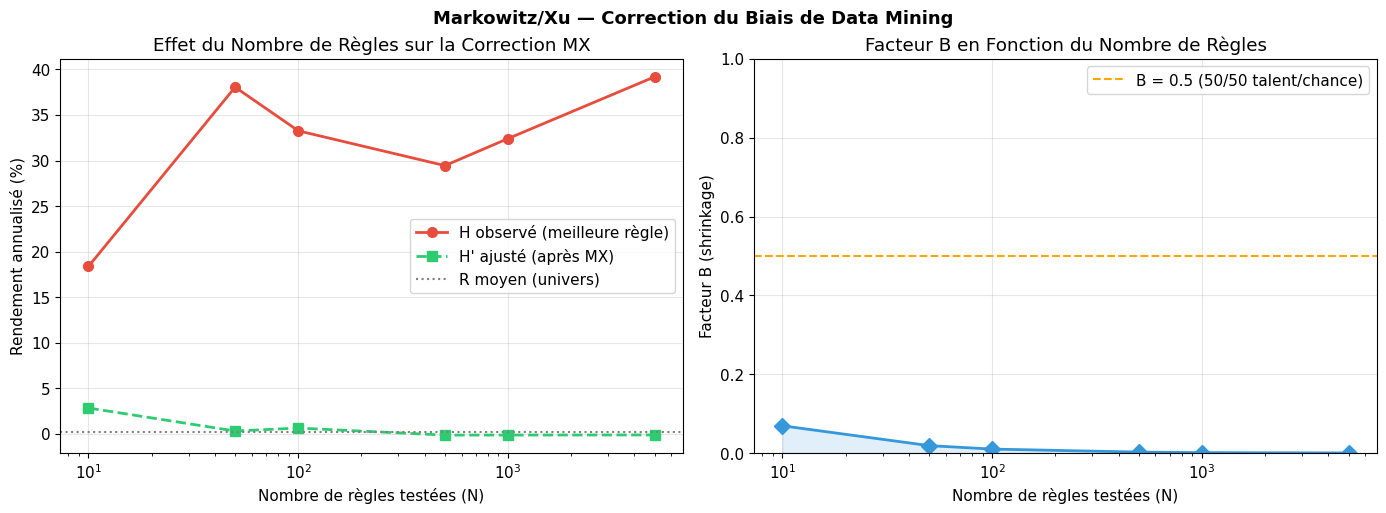

In [5]:
# ─── Visualisation de l'effet du shrinkage ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 : Performance observée vs ajustée selon N
ax1 = axes[0]
ax1.plot(n_rules_list, results_df['H_observed'] * 100, 'o-', color='#e74c3c',
         linewidth=2, markersize=7, label='H observé (meilleure règle)')
ax1.plot(n_rules_list, results_df['H_adjusted'] * 100, 's--', color='#2ecc71',
         linewidth=2, markersize=7, label="H' ajusté (après MX)")
ax1.axhline(y=results_df['R_average'].mean() * 100, color='gray',
            linestyle=':', linewidth=1.5, label='R moyen (univers)')
ax1.set_xscale('log')
ax1.set_xlabel('Nombre de règles testées (N)')
ax1.set_ylabel('Rendement annualisé (%)')
ax1.set_title('Effet du Nombre de Règles sur la Correction MX')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Graphique 2 : Facteur B (shrinkage) selon N
ax2 = axes[1]
ax2.plot(n_rules_list, results_df['B_shrinkage'], 'D-', color='#3498db',
         linewidth=2, markersize=8)
ax2.fill_between(n_rules_list, results_df['B_shrinkage'], alpha=0.15, color='#3498db')
ax2.axhline(y=0.5, color='orange', linestyle='--', linewidth=1.5, label='B = 0.5 (50/50 talent/chance)')
ax2.set_xscale('log')
ax2.set_xlabel('Nombre de règles testées (N)')
ax2.set_ylabel('Facteur B (shrinkage)')
ax2.set_title('Facteur B en Fonction du Nombre de Règles')
ax2.set_ylim(0, 1)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Markowitz/Xu — Correction du Biais de Data Mining', y=1.02,
             fontsize=13, fontweight='bold')
plt.show()

In [6]:
# ─── Comparaison : stratégie avec et sans vrai edge ─────────────────────────
print("\nCAS 1 : Pur bruit (true_edge = 0%)")
print("-" * 50)
df_noise = simulate_rules_universe(500, 504, true_edge=0.00)
H, R, sR, sH, N, T = analyze_universe(df_noise)
r = markowitz_xu_correction(H, R, sR, sH, N, T)
print(f"  H observé   : {r['H_observed']*100:.1f}%")
print(f"  B           : {r['B_shrinkage']}")
print(f"  H' ajusté   : {r['H_adjusted']*100:.1f}%  ← proche de R")

print("\nCAS 2 : Avec vrai edge (true_edge = 5% annuel)")
print("-" * 50)
df_edge = simulate_rules_universe(500, 504, true_edge=0.05)
H2, R2, sR2, sH2, N2, T2 = analyze_universe(df_edge)
r2 = markowitz_xu_correction(H2, R2, sR2, sH2, N2, T2)
print(f"  H observé   : {r2['H_observed']*100:.1f}%")
print(f"  B           : {r2['B_shrinkage']}")
print(f"  H' ajusté   : {r2['H_adjusted']*100:.1f}%  ← conserve une partie de l'edge réel")


CAS 1 : Pur bruit (true_edge = 0%)
--------------------------------------------------
  H observé   : 30.8%
  B           : 0.0025
  H' ajusté   : 0.2%  ← proche de R

CAS 2 : Avec vrai edge (true_edge = 5% annuel)
--------------------------------------------------
  H observé   : 35.4%
  B           : 0.0022
  H' ajusté   : 5.0%  ← conserve une partie de l'edge réel


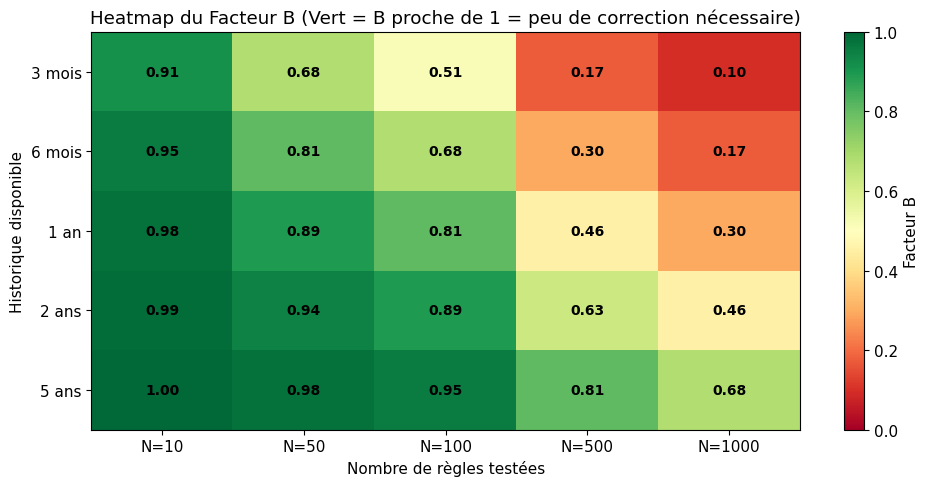

In [7]:
# ─── Sensibilité du facteur B ────────────────────────────────────────────────
# Visualiser B en fonction de N (règles) et T (périodes) simultanément

N_values = np.array([10, 50, 100, 500, 1000])
T_values = np.array([63, 126, 252, 504, 1260])  # 3m, 6m, 1an, 2ans, 5ans

sigma_R_sq_fixed = 0.0005
sigma_H_sq_fixed = 0.0003

# Matrice des facteurs B
B_matrix = np.zeros((len(T_values), len(N_values)))

for i, T in enumerate(T_values):
    for j, N in enumerate(N_values):
        s = sigma_R_sq_fixed / N
        n = sigma_H_sq_fixed / T
        B_matrix[i, j] = s / (s + n)

# Heatmap
fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(B_matrix, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')

ax.set_xticks(range(len(N_values)))
ax.set_xticklabels([f'N={n}' for n in N_values])
ax.set_yticks(range(len(T_values)))
ax.set_yticklabels(['3 mois', '6 mois', '1 an', '2 ans', '5 ans'])
ax.set_xlabel('Nombre de règles testées')
ax.set_ylabel('Historique disponible')
ax.set_title('Heatmap du Facteur B (Vert = B proche de 1 = peu de correction nécessaire)')

# Annotations
for i in range(len(T_values)):
    for j in range(len(N_values)):
        ax.text(j, i, f'{B_matrix[i,j]:.2f}', ha='center', va='center',
                color='black', fontsize=10, fontweight='bold')

plt.colorbar(im, ax=ax, label='Facteur B')
plt.tight_layout()
plt.show()

## Conclusion

La méthode Markowitz/Xu apporte une réponse élégante à un problème fondamental du backtesting :

- Elle utilise **100\% de l'historique** disponible (aucun OOS requis)
- Elle donne une **estimation de la performance dégradée** avant tout test lourd
- Le facteur $B$ synthétise la tension **signal vs bruit** en un seul chiffre

**À retenir :**
- Plus on teste de règles, plus $B$ s'effondre vers 0
- Un historique long augmente $B$ (plus d'observations = moins de bruit)
- C'est un **filtre rapide**, pas une garantie absolue

> **L'Eurêka :** La méthode MX ne valide pas une stratégie — elle quantifie à quel point ton backtest est contaminé par la chance. Si après shrinkage ton edge disparaît, c'est la chance qui avait gagné, pas ta stratégie.

## Annexe — Texte Original (CH 6 : Markowitz/Xu Data Mining Correction Factor)

### **CH 6 : MARKOWITZ/XU DATA MINING CORRECTION FACTOR**

Cette section présente une approche mathématique alternative pour corriger le biais de minage de données sans recourir à la segmentation des données (In-Sample / Out-of-Sample).

#### **Idées clés :**
*   **Correction par "Shrinkage" (Contraction) :** La méthode MX réduit la performance du meilleur candidat en la ramenant vers la moyenne de toutes les règles testées.
*   **Utilisation intégrale des données :** Contrairement aux tests hors-échantillon, cette méthode ne nécessite pas de réserver une partie de l'historique, permettant ainsi d'utiliser toutes les observations pour la recherche.
*   **Variables déterminantes :** L'ampleur de la correction dépend de la variance des rendements, du nombre de règles examinées et du nombre d'intervalles de temps.
*   **Estimation approximative :** Bien qu'utile, Aronson avertit que cette méthode doit être utilisée comme une directive générale ("rough guideline") car elle peut échouer dans certaines conditions.

#### **Référence :**
*Markowitz/Xu Data Mining Correction Factor*, Chapitre 6, pages 323 à 324.

#### **Citation Directe :**
« The method corrects for the data-mining bias by shrinking the observed performance of the best rule back toward the average performance of all rules tested. » (Page 323).

---

#### **Vision Macro :**
L'enjeu est de trouver un compromis entre la puissance de recherche et la validité statistique. David Aronson explique que la segmentation des données (OOS) "consomme" une ressource finie : l'historique. La méthode Markowitz/Xu propose une solution purement statistique : si vous avez testé 1 000 règles, votre "gagnant" a mathématiquement bénéficié d'une part de chance. Au lieu de vérifier cela sur de nouvelles données, on applique une "amende" mathématique au profit observé pour estimer ce qu'il restera une fois la chance évaporée.

---

#### **Vision Micro :**

Le mécanisme repose sur le calcul d'un rendement attendu ajusté ($H'$) via une formule de contraction :

**$H' = R + B(H - R)$**

1.  **Les composants :**
    *   **$H$ (Observed Performance) :** Le rendement brut du meilleur candidat trouvé par le backtest.
    *   **$R$ (Average Return) :** La moyenne des rendements de *toutes* les règles testées dans l'univers de recherche.
    *   **$B$ (Shrinkage Factor) :** Un facteur compris entre 0 et 1 qui détermine l'intensité de la correction.
2.  **Le rôle du facteur $B$ :**
    *   Si $B$ est proche de **0**, le biais détecté est énorme ; la performance future attendu ($H'$) est alors presque égale à la moyenne de l'univers ($R$).
    *   Si $B$ est proche de **1**, le biais est jugé négligeable ; la performance observée ($H$) est considérée comme représentative du futur.
3.  **Facteurs influençant $B$ :** Le calcul de $B$ (souvent via un tableur Excel comme proposé par De La Maza) prend en compte la variation des rendements quotidiens de chaque règle et la dispersion des moyennes de l'univers par rapport à la moyenne globale.

---

#### **Résumé Simplifié :**
Imaginez un concours de pronostics entre 1 000 personnes. Le gagnant a eu 90% de réussite. La méthode Markowitz/Xu dit : « Sur 1 000 personnes, il est obligé qu'il y en ait une qui ait eu beaucoup de chance. Je vais donc rabaisser son score de 90% à 60% pour être plus proche de son talent réel. » C'est une "douche froide" mathématique pour les backtests trop beaux pour être vrais.

---

#### **Actions Concrètes :**
*   **Enregistrer l'intégralité des tests :** Pour appliquer cette formule, vous devez conserver les rendements de toutes les règles testées, pas seulement ceux du gagnant.
*   **Utiliser comme filtre rapide :** Appliquez la formule MX pour obtenir une estimation immédiate de la dégradation de performance à attendre avant de lancer des tests Monte Carlo plus lourds.
*   **Rester prudent :** Ne considérez pas le résultat $H'$ comme une certitude absolue, mais plutôt comme une limite supérieure de ce que la stratégie pourrait réellement produire.

---

#### **À retenir absolument :**
*   La méthode MX **"dégonfle" l'optimisme** du backtest.
*   Elle ramène le champion vers la **moyenne de la foule** (shrinkage).
*   Elle permet d'utiliser **100% de l'historique** pour le minage.
*   Le facteur **$B$** mesure la part de talent présumée par rapport à la chance.
*   C'est une **approximation** à utiliser avec esprit critique.